# Исследование поведения слушателей Яндекс Музыки

Сервисы потоковой музыки живут за счёт того, насколько хорошо они понимают своих слушателей. Если рекомендация попадает в настроение — пользователь дослушивает трек до конца, ставит лайк и возвращается завтра. Если промахивается — переключает и постепенно теряет доверие к сервису.

В этом исследовании мы возьмём открытый датасет Yambda от Яндекс Музыки и попробуем понять, как пользователи на самом деле взаимодействуют с музыкой: что они дослушивают, что бросают, в чём разница между "найденным самостоятельно" треком и тем, что предложил алгоритм. И есть ли у сервиса небольшая группа "меломанов", которая слушает в разы больше остальных.

## О данных

Yambda-50M - открытая выборка из ~47 млн событий прослушивания, опубликованная Яндексом на Hugging Face в мае 2025 года. Это подмножество полного датасета на 5 миллиардов событий - 10 000 случайных пользователей за 10 месяцев наблюдений.

В файле `listens.parquet` шесть колонок:

| Колонка | Тип | Описание |
|---|---|---|
| `uid` | uint32 | ID пользователя |
| `timestamp` | uint32 | Временная метка события (в минутах от начала периода наблюдений) |
| `item_id` | uint32 | ID трека |
| `is_organic` | uint8 | 1 — пользователь сам нашёл трек, 0 — алгоритм рекомендации |
| `played_ratio_pct` | uint16 | Какую долю трека прослушали, в процентах |
| `track_length_seconds` | uint32 | Длина трека в секундах |

## Гипотезы

Прежде чем смотреть на данные, сформулируем три предположения, которые будем проверять.

**Гипотеза 1.** Треки, которые пользователь нашёл сам, дослушиваются до конца чаще, чем те, что предложил алгоритм. Логика простая: когда человек сам ищет конкретную песню, он уже знает, что хочет её услышать. Рекомендация — это всегда лотерея.

**Гипотеза 2.** Короткие треки дослушиваются чаще длинных. Чем длиннее песня, тем выше шанс, что у слушателя закончится терпение, поездка в метро или рабочая задача.

**Гипотеза 3.** В сервисе есть небольшая группа пользователей-"меломанов", которые генерируют непропорционально большую долю всех прослушиваний. Это важно для бизнеса: понимая, кто эти люди, можно делать продукт лучше под них.

Кроме гипотез, проведём общее исследование данных: посмотрим на распределения, найдём аномалии, изучим разницу между типами слушателей.

## План исследования

1. Обзор данных - первый взгляд, размеры, типы, пропуски
2. Предобработка — аномалии, новые признаки
3. Исследовательский анализ — распределения ключевых метрик
4. Проверка гипотезы 1: органика vs рекомендации
5. Проверка гипотезы 2: длина трека и дослушиваемость
6. Проверка гипотезы 3: распределение активности пользователей
7. Сегментация пользователей
8. Общие выводы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_parquet('../dataset/listens.parquet')
print(f'Строк: {len(df):,}')
print(f'Столбцов: {df.shape[1]}')
df.head(10)

Строк: 46,467,212
Столбцов: 6


,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds
0,100,39420,8326270,0,100,170
1,100,39420,1441281,0,100,105
2,100,39625,286361,0,100,185
3,100,40110,732449,0,100,240
4,100,40360,3397170,0,46,130
5,100,40380,7849270,0,100,205
6,100,40640,1449307,0,100,205
7,100,40785,6887232,0,100,145
8,100,40885,2996197,0,100,95
9,100,41130,6474571,0,100,245


In [3]:
df.dtypes

uid                     uint32
timestamp               uint32
item_id                 uint32
is_organic               uint8
played_ratio_pct        uint16
track_length_seconds    uint32
dtype: object

In [4]:
df.describe()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds
count,46467212.00,46467212.00,46467212.00,46467212.00,46467212.00,46467212.00
mean,498499.04,14448380.92,4713863.83,0.52,64.76,207.41
std,287300.10,7463941.69,2701184.22,0.50,44.09,89.21
min,100.00,0.00,22.00,0.00,0.00,5.00
25%,249400.00,8207915.00,2396488.00,0.00,7.00,165.00
50%,494200.00,15089450.00,4715228.00,1.00,100.00,200.00
75%,744600.00,21057150.00,7050175.00,1.00,100.00,230.00
max,1000000.00,26000000.00,9390623.00,1.00,159.00,2495.00


In [5]:
df.nunique()

uid                        9238
timestamp               5047118
item_id                  877168
is_organic                    2
played_ratio_pct            160
track_length_seconds        499
dtype: int64

In [6]:
print(df['is_organic'].value_counts(normalize=True))

is_organic
1   0.52
0   0.48
Name: proportion, dtype: float64


В нашем датасете находится почти 50 миллионов строк и 6 столбцов. Уникальных пользователей 9238, уникальных треков 877168.
Так же можем заметить, что соотношение органических треков, и тех, что предложил алгоритм почти равно, 51.6% на 48.4%
Можно заметить аномалию в прослушивании трека - максимальное значен 159 (предположительно, пользователь слушал трек на повторе)

Средняя длина трека по медиане примерно 3 минуты (207 секунд), минимальная 5 секунд(очень короткий трек), а максимальная - около 41 минуты(2495 секунд)

## 2. Предобработка данных

**Поиск пропусков**

In [7]:
df.isna().sum()

uid                     0
timestamp               0
item_id                 0
is_organic              0
played_ratio_pct        0
track_length_seconds    0
dtype: int64

In [8]:
total_duplicates = df.duplicated().sum()
print(total_duplicates)

225625


In [9]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(df.shape)

(46241587, 6)


**Теперь посчитаем сколько треков имеют аномельное значение >100**

In [10]:
print(f'Строк с played_ratio_pct > 100: {(df["played_ratio_pct"] > 100).sum():,}')

Строк с played_ratio_pct > 100: 215,571


**Теперь заменим все значения  >100 на 100**

In [11]:
df['played_ratio_pct'] = df['played_ratio_pct'].clip(upper=100)

**Теперь пример за дослушанный трек 80% от прослушивания, который будет равен 1, иначе ставим 0**

In [12]:
df['is_completed'] = (df['played_ratio_pct'] >= 80).astype(int)

**Добавим новый столбец track_length_minutes**

В нем переведем секунды в минуты, чтобы картина данных была более ясной

In [13]:
df['track_length_minutes'] = df['track_length_seconds'] /60

df.head()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,is_completed,track_length_minutes
0,100,39420,8326270,0,100,170,1,2.83
1,100,39420,1441281,0,100,105,1,1.75
2,100,39625,286361,0,100,185,1,3.08
3,100,40110,732449,0,100,240,1,4.00
4,100,40360,3397170,0,46,130,0,2.17


**Определяем длину трека, разбив по категориям**

In [14]:
df['track_length_cat'] = pd.cut(
    df['track_length_seconds'],
    bins=[0, 120, 210, 300, 99999],
    labels=['короткий (<2 мин)', 'средний (2-3.5 мин)', 'длинный (3.5-5 мин)', 'очень длинный (>5 мин)']
)

df.head()

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,is_completed,track_length_minutes,track_length_cat
0,100,39420,8326270,0,100,170,1,2.83,средний (2-3.5 мин)
1,100,39420,1441281,0,100,105,1,1.75,короткий (<2 мин)
2,100,39625,286361,0,100,185,1,3.08,средний (2-3.5 мин)
3,100,40110,732449,0,100,240,1,4.00,длинный (3.5-5 мин)
4,100,40360,3397170,0,46,130,0,2.17,средний (2-3.5 мин)


Пропуски в датасете обнаружены не были, а дубликатов строк было уже найдено более 200 000, поэтому мы их удалили.
Далее избавились от аномалий, где прослушиваемость трека была  >100% и заменили на 100%

Были созданы 2 новых признака: длина трека и прослушал пользователь трек(1) или нет(0), за 1 принимаем >=80%


## 3. Исследовательский анализ (EDA)

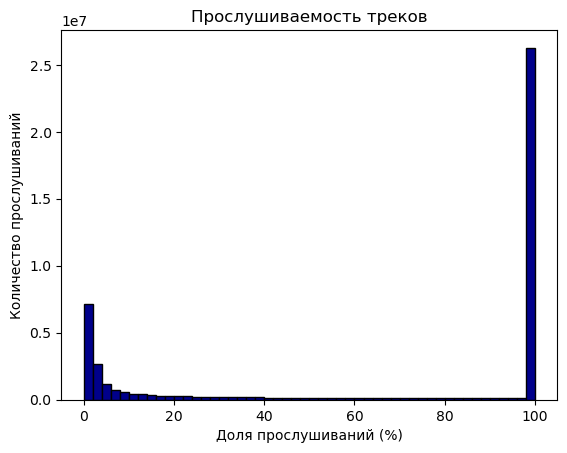

In [15]:
plt.hist(df['played_ratio_pct'], bins=50, color='darkblue', edgecolor='black')

plt.title('Прослушиваемость треков')
plt.xlabel('Доля прослушиваний (%)')
plt.ylabel('Количество прослушиваний')

plt.show()

In [16]:
print(df['is_completed'].value_counts(normalize=True))

is_completed
1   0.59
0   0.41
Name: proportion, dtype: float64


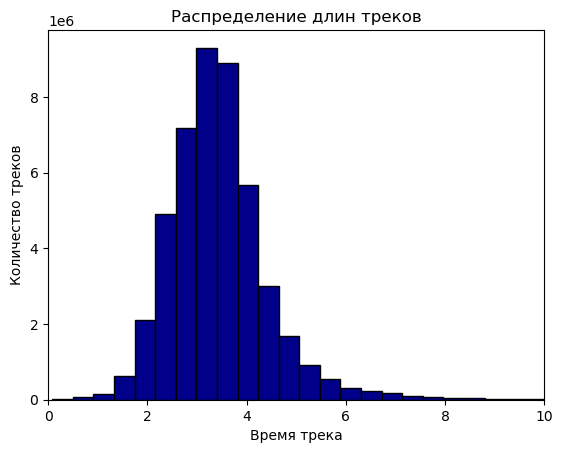

In [17]:
plt.hist(df['track_length_minutes'], bins=100, color='darkblue', edgecolor='black')

plt.title('Распределение длин треков')
plt.xlabel('Время трека')
plt.ylabel('Количество треков')
plt.xlim(0, 10)

plt.show()

In [18]:
print(df['track_length_cat'].value_counts())
print()
print(df['track_length_cat'].value_counts(normalize=True))

track_length_cat
средний (2-3.5 мин)       25759829
длинный (3.5-5 мин)       15532260
очень длинный (>5 мин)     2642086
короткий (<2 мин)          2307412
Name: count, dtype: int64

track_length_cat
средний (2-3.5 мин)      0.56
длинный (3.5-5 мин)      0.34
очень длинный (>5 мин)   0.06
короткий (<2 мин)        0.05
Name: proportion, dtype: float64


**Найдем самые прослушиваемые треки и самых активных пользователей**

In [19]:
df.groupby('item_id').size().sort_values(ascending=False).head(10)

item_id
5862961    41631
6901374    40511
3542184    39621
5635052    38528
9378983    38491
5463340    37908
8213481    37309
906358     35618
3033749    29759
2859641    29452
dtype: int64

In [20]:
df.groupby('uid').size().sort_values(ascending=False).head(10)

uid
83700     27616
997500    27494
358100    27288
990300    27176
646100    27152
509900    27106
181000    27077
423900    27073
727600    26993
84300     26725
dtype: int64

In [21]:
user_listens = df.groupby('uid').size()
user_listens.describe(percentiles=[0.25,0.5,0.75,0.95,0.99])

count    9238.00
mean     5005.58
std      5497.30
min         5.00
25%       931.25
50%      3009.00
75%      7139.00
95%     17300.00
99%     23724.23
max     27616.00
dtype: float64

**Вывод по EDA**

По нашим данным 59% треков из датасета прослушиваются до конца.

56% треков длятся 2-3.5 минут, коротких же всего 5%

Самый прослушиваемый трек item_id = 5862961

Пользователь с id 5862961 прослушал больше всего треков(41631)

## 4. Гипотеза 1: органика vs рекомендации

Проверяем: дослушивают ли пользователи треки, которые нашли сами, чаще, чем рекомендации алгоритма.

In [22]:
df.groupby('is_organic')['is_completed'].mean()

is_organic
0   0.65
1   0.54
Name: is_completed, dtype: float64

In [23]:
print(df.groupby('is_organic')['played_ratio_pct'].mean())

is_organic
0   69.58
1   60.08
Name: played_ratio_pct, dtype: float64


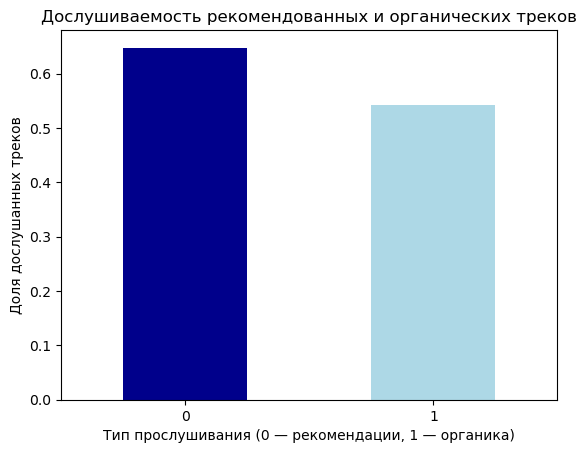

In [24]:
competition = df.groupby('is_organic')['is_completed'].mean()
competition.plot(kind='bar', color=['darkblue', 'lightblue'])

plt.title('Дослушиваемость рекомендованных и органических треков')
plt.xlabel('Тип прослушивания (0 — рекомендации, 1 — органика)')
plt.ylabel('Доля дослушанных треков')
plt.xticks(rotation=0)
plt.show()

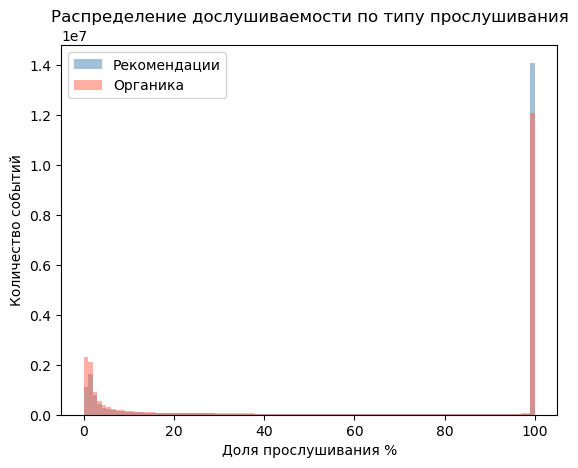

In [25]:
organic = df[df['is_organic'] == 1]['played_ratio_pct']
recommended = df[df['is_organic'] == 0]['played_ratio_pct']

plt.hist(recommended, bins=100, alpha=0.5, label='Рекомендации', color='steelblue')
plt.hist(organic, bins=100, alpha=0.5, label='Органика', color='tomato')

plt.title('Распределение дослушиваемости по типу прослушивания')
plt.xlabel('Доля прослушивания %')
plt.ylabel('Количество событий')
plt.legend()
plt.show()

Гипотеза **не подтвердилась**. 
Рекомендательный алгоритм показывает дослушиваемость 65% против 54% у органических прослушиваний. 
Это может говорить о том, что алгоритм Яндекс Музыки хорошо персонализирован

Посмотрев на графики, мы также можем заметить, что оба типа прослушивания показывают одинаковый результат: 
либо трек дослушивают до конца, либо сразу переключают. Из этого следует вывод, что решение, нравится/не нравится композиция, принимается быстро

## 5. Гипотеза 2: длина трека и дослушиваемость

Проверяем: правда ли, что чем короче трек, тем чаще его дослушивают до конца.

In [26]:
df.groupby('track_length_cat', observed = True)['is_completed'].mean()

track_length_cat
короткий (<2 мин)        0.64
средний (2-3.5 мин)      0.61
длинный (3.5-5 мин)      0.57
очень длинный (>5 мин)   0.52
Name: is_completed, dtype: float64

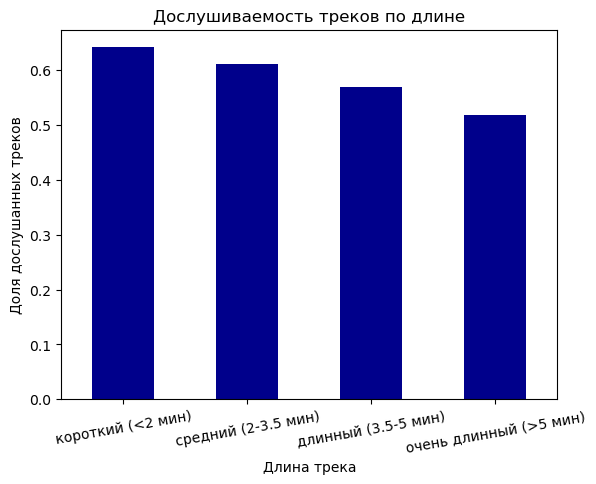

In [31]:
track_length = df.groupby('track_length_cat', observed = True)['is_completed'].mean()
track_length.plot(kind='bar', color = 'darkblue')

plt.title('Дослушиваемость треков по длине')
plt.xlabel('Длина трека')
plt.ylabel('Доля дослушанных треков')
plt.xticks(rotation=10)
plt.show()

Чтобы проверить, нет ли нелинейности на стыках категорий, построим scatter plot или линейный график зависимости средней дослушиваемости от длины трека (в минутах, с шагом 0.5 минуты)

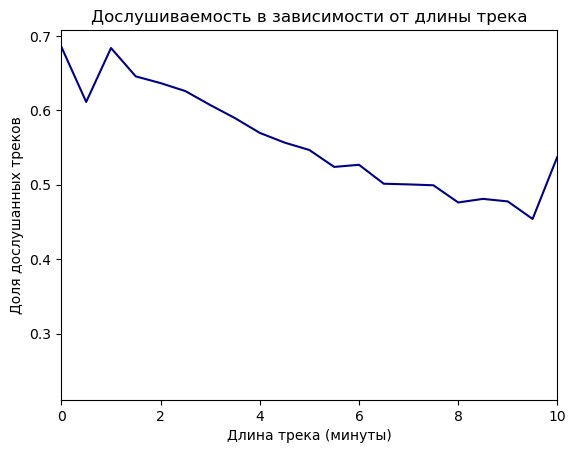

In [40]:
df['length_rounded'] = (df['track_length_minutes'] * 2).round() / 2
completion_by_length = df.groupby('length_rounded')['is_completed'].mean()

plt.plot(completion_by_length.index, completion_by_length.values, color='darkblue')

plt.title('Дослушиваемость в зависимости от длины трека')
plt.xlabel('Длина трека (минуты)')
plt.ylabel('Доля дослушанных треков')
plt.xlim(0, 10)
plt.show()

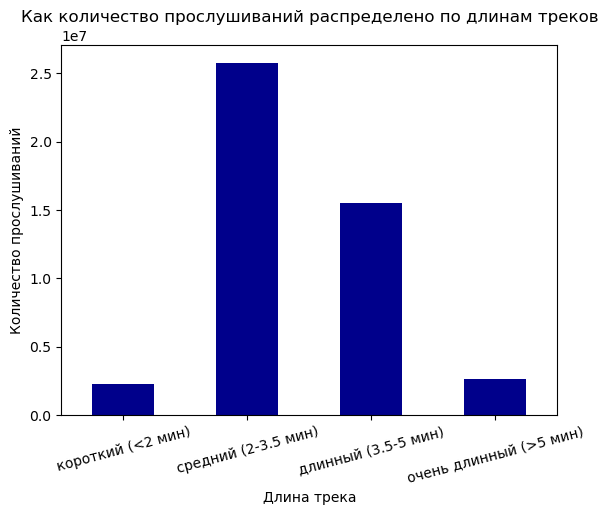

In [38]:
counts = df.groupby('track_length_cat', observed=True).size()

counts.plot(kind='bar', color='darkblue')

plt.title('Как количество прослушиваний распределено по длинам треков')
plt.xlabel('Длина трека')
plt.ylabel('Количество прослушиваний')
plt.xticks(rotation=15)
plt.show()

Гипотеза **подтвердилась**.
Прослеживается чёткая закономерность: чем длиннее трек, тем реже его дослушивают до конца. 
От 64% у коротких треков до 52% у очень длинных. Разница в 12% устойчива и видна как на категориальном графике, так и на детальном линейном. 

Данных достаточно по всем категориям для надёжных выводов.

## 6. Гипотеза 3: Активность пользователей распределена неравномерно: одни слушают больше треков, чем остальные

In [42]:
user_listens = df.groupby('uid').size().sort_values(ascending=False)
user_listens

uid
83700     27616
997500    27494
358100    27288
990300    27176
646100    27152
          ...  
85800        11
464400       10
231900        8
111100        7
65700         5
Length: 9238, dtype: int64

Построим кривую Лоренца: график зависимости накопленной доли прослушиваний от накопленной доли пользователей

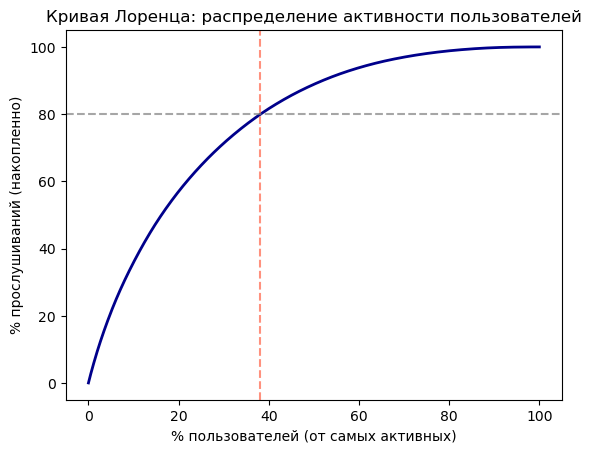

In [44]:
cumulative_listens = user_listens.cumsum() / user_listens.sum() * 100

n = len(user_listens)
user_pct = [i / n * 100 for i in range(1, n + 1)]

threshold_idx = (cumulative_listens <= 80).sum()
threshold_pct = threshold_idx / n * 100

plt.plot(user_pct, cumulative_listens.values, color='darkblue', linewidth=2)

plt.axhline(80, color='gray', linestyle='--', alpha=0.7)
plt.axvline(threshold_pct, color='tomato', linestyle='--', alpha=0.7)

plt.title('Кривая Лоренца: распределение активности пользователей')
plt.xlabel('% пользователей (от самых активных)')
plt.ylabel('% прослушиваний (накопленно)')
plt.show()

In [45]:
total = user_listens.sum()
n = len(user_listens)

cumulative = user_listens.cumsum() / total * 100

users_50 = (cumulative <= 50).sum()
print(f'{users_50} пользователей ({users_50/n*100:.1f}%) дают 50% всех прослушиваний')

users_80 = (cumulative <= 80).sum()
print(f'{users_80} пользователей ({users_80/n*100:.1f}%) дают 80% всех прослушиваний')

1495 пользователей (16.2%) дают 50% всех прослушиваний
3525 пользователей (38.2%) дают 80% всех прослушиваний


In [46]:
print(user_listens.describe())

count    9238.00
mean     5005.58
std      5497.30
min         5.00
25%       931.25
50%      3009.00
75%      7139.00
max     27616.00
dtype: float64


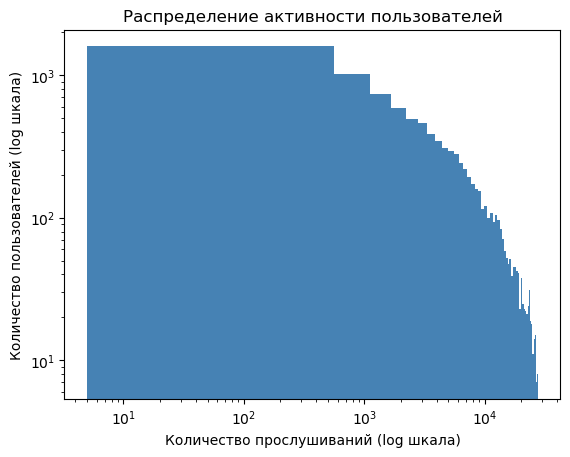

In [48]:
plt.hist(user_listens.values, bins=50, color='steelblue')

plt.xscale('log')
plt.yscale('log')

plt.title('Распределение активности пользователей')
plt.xlabel('Количество прослушиваний (log шкала)')
plt.ylabel('Количество пользователей (log шкала)')
plt.show()

Гипотеза **подтвердилась**.  
Активность пользователей распределена очень неравномерно:
всего 16.2% пользователей (1495 из 9238) генерируют 50% всех прослушиваний
38.2% пользователей дают 80% всех прослушиваний

Кривая Лоренца резко изгибается в начале и это визуальное подтверждение неравенства. Самый активный пользователь прослушал 27 616 треков, тогда как медианный 3 009, разница почти в 9 раз.
Следовательно, для сервиса небольшая группа суперактивных пользователей критически важна


## 7. Сегментация пользователей

Раз активность так неравномерна, имеет смысл разделить пользователей на сегменты и сравнить их поведение.

In [52]:
segments = pd.qcut(
    user_listens,
    q=4,
    labels=['низкая', 'средняя', 'высокая', 'очень высокая']
)

df['activity_segment'] = df['uid'].map(segments)

print(df['activity_segment'].value_counts())
df.head()

activity_segment
очень высокая    29953269
высокая          11139820
средняя           4241929
низкая             906569
Name: count, dtype: int64


,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,is_completed,track_length_minutes,track_length_cat,length_rounded,activity_segment
0,100,39420,8326270,0,100,170,1,2.83,средний (2-3.5 мин),3.00,высокая
1,100,39420,1441281,0,100,105,1,1.75,короткий (<2 мин),2.00,высокая
2,100,39625,286361,0,100,185,1,3.08,средний (2-3.5 мин),3.00,высокая
3,100,40110,732449,0,100,240,1,4.00,длинный (3.5-5 мин),4.00,высокая
4,100,40360,3397170,0,46,130,0,2.17,средний (2-3.5 мин),2.00,высокая


In [53]:
df.groupby('activity_segment', observed=True).agg(
    дослушиваемость=('is_completed', 'mean'),
    доля_органики=('is_organic', 'mean'),
    средняя_длина=('track_length_seconds', 'mean')
).round(2)

,дослушиваемость,доля_органики,средняя_длина
activity_segment,,,
низкая,0.57,0.56,211.52
средняя,0.60,0.53,208.17
высокая,0.61,0.52,209.09
очень высокая,0.59,0.51,206.01


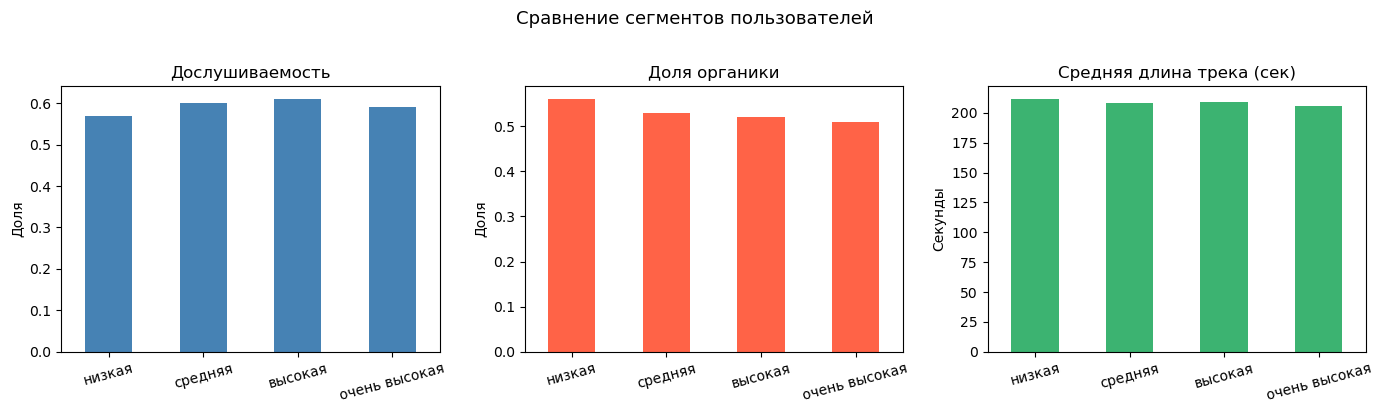

In [54]:
segment_stats = df.groupby('activity_segment', observed=True).agg(
    дослушиваемость=('is_completed', 'mean'),
    доля_органики=('is_organic', 'mean'),
    средняя_длина=('track_length_seconds', 'mean')
).round(2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

segment_stats['дослушиваемость'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Дослушиваемость')
axes[0].set_ylabel('Доля')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

segment_stats['доля_органики'].plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Доля органики')
axes[1].set_ylabel('Доля')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

segment_stats['средняя_длина'].plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Средняя длина трека (сек)')
axes[2].set_ylabel('Секунды')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Сравнение сегментов пользователей', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Сегментация по активности показала неожиданный результат: поведение пользователей почти не зависит от того, сколько они слушают.

Дослушиваемость практически одинакова во всех сегментах от 57% у пассивных до 61% у высокой группы. То есть количество прослушанных треков не влияет на дослушиваемость

Доля органики слегка убывает с ростом активности: пассивные пользователи чаще сами ищут треки (56%), суперактивные больше полагаются на рекомендации (51%). Возможное объяснение: активные пользователи доверяют алгоритму находить новое.

Средняя длина треков практически не отличается: все сегменты слушают треки примерно по 3.5 минуты.


**Вывод**: активные и пассивные пользователи слушают музыку примерно одинаково и разница только в количестве, но не в характере прослушивания

## 9. Общие выводы

**Гипотеза 1**: **Опровергнута**. Рекомендательный алгоритм показывает дослушиваемость 65% против 54% у органических прослушиваний. Пользователи дослушивают треки из рекомендаций чаще, чем те, что нашли сами — вероятно, алгоритм Яндекс Музыки хорошо персонализирован и попадает в предпочтения точнее, чем сам пользователь.

**Гипотеза 2**: **Подтверждена**. Чем длиннее трек, тем реже его дослушивают до конца. От 64% у коротких треков (до 2 минут) до 52% у очень длинных (свыше 5 минут).

**Гипотеза 3**: **Подтверждена**. 16% пользователей генерируют 50% всех прослушиваний, а 38% пользователей — 80%. Самый активный пользователь прослушал 27 616 треков, а медианный 3 009. Активность распределена крайне неравномерно.

**Главные числа исследования**:

46.5 млн прослушиваний, 9 238 пользователей, 877 168 уникальных треков
Медианный пользователь  3 009 прослушиваний
Общая дослушиваемость — около 59%
Соотношение органики и рекомендаций — почти 50/50